In [1]:
from pathlib import Path

Path("images").mkdir(parents=True, exist_ok=True)
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import sklearn
import shap
import time

shap.initjs()

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from IPython.display import display


def display_and_save(fig, path, **kwargs):
    """Display the finished figure, then save it relative to the working directory."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    display(fig)
    fig.savefig(path, **kwargs)
    plt.close(fig)


C:\Users\zzz\.conda\envs\automl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = Path("dataset.xlsx")
if not data_path.exists():
    raise FileNotFoundError(f"找不到数据文件：{data_path}")

file_data = pd.read_excel(data_path)
print(f"数据读取成功：{data_path}")
print(f"数据维度：{file_data.shape}")


FEATURE_LABELS = {
    "s/a": r"$\mathrm{s}/\mathrm{a}$",
    "w/c": r"$\mathrm{w}/\mathrm{c}$",
    "s/c": r"$\mathrm{s}/\mathrm{c}$",
    "a/c": r"$\mathrm{a}/\mathrm{c}$",
    "smax/mm": r"$s_{\mathrm{max}}$",
    "Vf/%": r"$V_{\mathrm{f}}$",
    "l/d": r"$\ell/\mathrm{d}$",
    "fc/MPa": r"$f_{\mathrm{c}}$",
    "fc0/MPa": r"$f_{\mathrm{c0}}$",
}

def apply_shap_feature_labels(values, columns):
    """Attach Matplotlib MathText labels without changing model input columns."""
    values.feature_names = [FEATURE_LABELS.get(name, name) for name in columns]
    return values

X = file_data.drop(columns=["fc/MPa"])
y = file_data["fc/MPa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=82
)

def print_accuracy(f):
    predictions = f(X_test)
    print("Root mean squared test error = {0}".format(
        np.sqrt(np.mean((predictions - y_test) ** 2))
    ))
    time.sleep(0.5)


数据读取成功：dataset.xlsx
数据维度：(270, 9)


In [3]:
label = "fc/MPa"
feature_names = X_train.columns

train_data = X_train.copy()
train_data[label] = y_train

val_data = X_test.copy()

# Pandas 表格使用原始列名；LaTeX 标签仅交给 Matplotlib/SHAP 渲染。
display(train_data.head())


,s/a,w/c,s/c,a/c,smax/mm,Vf/%,l/d,fc0/MPa,fc/MPa
92,0.950000,0.330000,1.690000,1.790000,20.0,2.40,50.0,39.6,41.20
186,0.680000,0.350000,1.590000,2.340000,10.0,1.50,80.0,61.7,77.30
128,0.872664,0.565179,2.223214,2.547619,10.0,1.20,57.6,53.7,58.80
109,0.950000,0.330000,1.690000,1.790000,20.0,1.71,70.0,39.6,44.81
15,0.560000,0.280000,0.970000,1.730000,19.0,1.00,60.0,103.6,106.60


In [4]:
predictor = TabularPredictor(label=label, problem_type='regression').fit(train_data, time_limit=60)

No path specified. Models will be saved in: "AutogluonModels\ag-20260907_131712"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.1
Python Version:     3.12.8
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          16
Memory Avail:       10.61 GB / 31.84 GB (33.3%)
Disk Space Avail:   22.59 GB / 314.90 GB (7.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competitions and benchmarks.
	presets='high'        

[1000]	valid_set's rmse: 5.99872
[2000]	valid_set's rmse: 4.6873
[3000]	valid_set's rmse: 4.11114
[4000]	valid_set's rmse: 3.80095
[5000]	valid_set's rmse: 3.64406
[6000]	valid_set's rmse: 3.56304
[7000]	valid_set's rmse: 3.51079
[8000]	valid_set's rmse: 3.49356
[9000]	valid_set's rmse: 3.48615
[10000]	valid_set's rmse: 3.4783


	-3.4775	 = Validation score   (-root_mean_squared_error)
	1.13s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 56.52s of the 56.52s of remaining time.


[1000]	valid_set's rmse: 3.58371
[2000]	valid_set's rmse: 3.45852


	-3.4454	 = Validation score   (-root_mean_squared_error)
	0.37s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 56.03s of the 56.03s of remaining time.
	-3.2178	 = Validation score   (-root_mean_squared_error)
	0.43s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 55.55s of the 55.55s of remaining time.
	-3.5492	 = Validation score   (-root_mean_squared_error)
	1.05s	 = Training   runtime
	0.0s	 = Validation runtime
Fitting model: ExtraTreesMSE ... Training model for up to 54.49s of the 54.49s of remaining time.
	-3.1036	 = Validation score   (-root_mean_squared_error)
	0.38s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: NeuralNetFastAI ... Training model for up to 54.06s of the 54.06s of remaining time.
	-3.6441	 = Validation score   (-root_mean_squared_error)
	1.48s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ... Tra

In [5]:
class AutogluonWrapper:
    def __init__(self, predictor, feature_names):
        self.ag_model = predictor
        self.feature_names = feature_names
    
    def predict(self, X):
        if isinstance(X, pd.Series):
            X = X.values.reshape(1,-1)
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)
        return self.ag_model.predict(X)

In [6]:
ag_wrapper = AutogluonWrapper(predictor, feature_names)
print_accuracy(ag_wrapper.predict)

explainer = shap.KernelExplainer(ag_wrapper.predict, X_train)

NSHAP_SAMPLES = 100  # how many samples to use to approximate each Shapely value, larger values will be slower
N_VAL = 30  # how many datapoints from validation data should we interpret predictions for, larger values will be slower

Root mean squared test error = 3.3906685230883307


ExactExplainer explainer: 55it [01:34,  1.86s/it]                                                                      


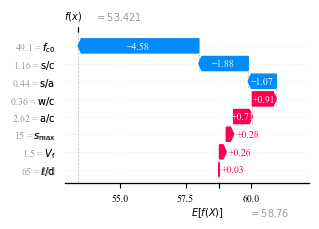

In [12]:
import shap
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False  # 处理负号显示问题（可选）


explainer = shap.Explainer(predictor.predict, X_train)
shap_values = explainer(X_test)
shap_values = apply_shap_feature_labels(shap_values, X_test.columns)


ax = shap.plots.waterfall(shap_values[13], show=False)

fig = ax.figure


fig.set_size_inches(8 * cm, 5 * cm)


for text in fig.findobj(match=plt.Text):
    if text.get_text().strip() == '=':
        x, y = text.get_position()
        text.set_position((x - 0.2, y))  # 微调等号位置
    text.set_fontsize(7)


display_and_save(plt.gcf(), "images/shap_values13_plot.png", dpi=600, bbox_inches='tight')


ExactExplainer explainer: 55it [01:27,  1.82s/it]                                                                      


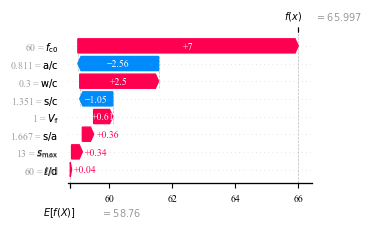

In [13]:
import shap
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = True  

explainer = shap.Explainer(predictor.predict, X_train)
shap_values = explainer(X_test)
shap_values = apply_shap_feature_labels(shap_values, X_test.columns)

# 返回的是 Axes 对象
ax = shap.plots.waterfall(shap_values[10], show=False)

# 获取对应的 Figure 对象
fig = ax.figure

# 设置图像尺寸为 7cm × 5cm（转换为英寸）
cm = 1 / 2.54
fig.set_size_inches(8 * cm, 5 * cm)

for text in fig.findobj(match=plt.Text):
    text.set_fontsize(7)
# 保存图像
display_and_save(plt.gcf(), "images/shap_values10_plot.png", dpi=600, bbox_inches='tight')


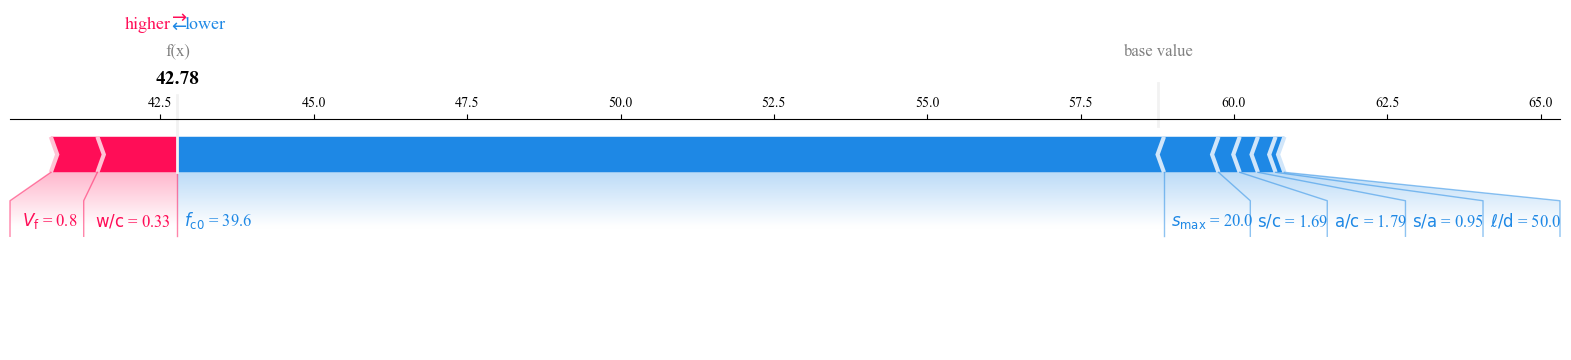

In [14]:
import shap
import matplotlib.pyplot as plt

shap.initjs()


shap.plots.force(shap_values[0], matplotlib=True, show=False)

fig = plt.gcf()


display_and_save(plt.gcf(), 'images/0_Force_plot.png', bbox_inches='tight', dpi=600)


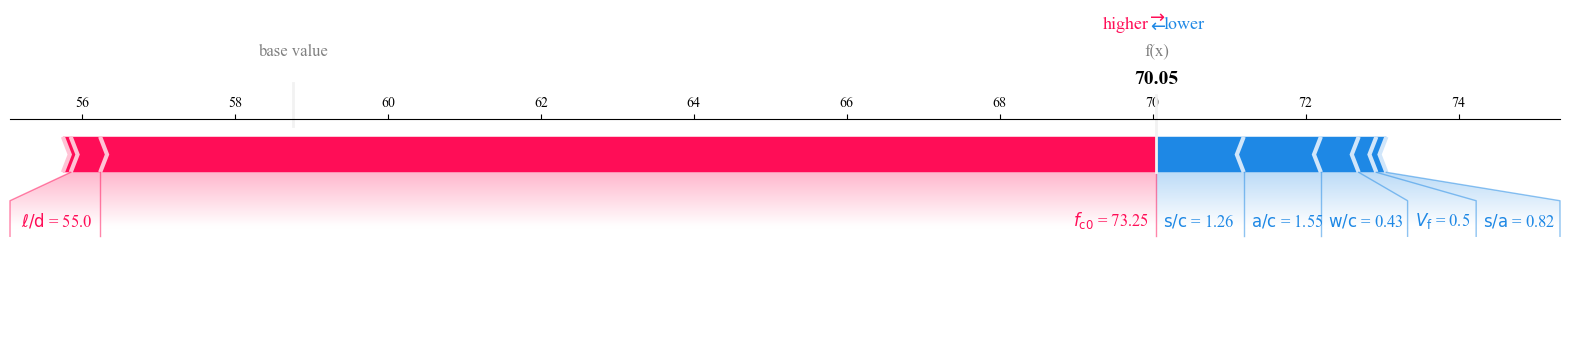

In [15]:
import shap
import matplotlib.pyplot as plt

shap.initjs()


shap.plots.force(shap_values[2], matplotlib=True, show=False)


fig = plt.gcf()


display_and_save(plt.gcf(), 'images/2_Force_plot.png', bbox_inches='tight', dpi=600)


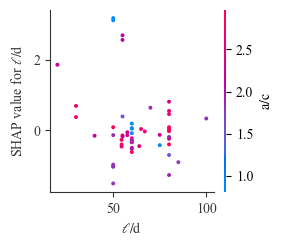

In [17]:
import shap
import matplotlib.pyplot as plt

# 全局字体设置为 Times New Roman，小尺寸图建议字体小些
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10  # 更适合 8×6 cm 图
plt.rcParams['axes.unicode_minus'] = False


cm = 1 / 2.54
fig_width, fig_height = 8 * cm, 6 * cm


shap_values_array = shap_values.values


shap.dependence_plot(
    "l/d",
    shap_values_array,
    X_test,
    interaction_index="a/c",
    show=False,
    dot_size=8  # 推荐用于小画布
)


fig = plt.gcf()
fig.set_size_inches(fig_width, fig_height)


plt.xlabel(FEATURE_LABELS['l/d'], fontsize=10)
plt.ylabel("")
plt.gca().set_ylabel(r"SHAP value for $\ell/\mathrm{d}$", fontsize=10, rotation=90, labelpad=6)



plt.xticks(fontsize=10)
plt.yticks(fontsize=10)


ax = plt.gca()
cbar = ax.collections[0].colorbar
cbar.set_label(FEATURE_LABELS['a/c'], fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=10)


fig.subplots_adjust(left=0.20, right=0.85, top=0.95, bottom=0.18)


display_and_save(plt.gcf(), "images/3_dependence_plot_small_font.png", dpi=600, bbox_inches="tight")


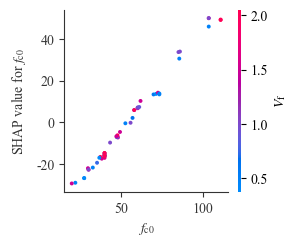

In [18]:
import shap
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False


cm = 1 / 2.54
fig_width, fig_height = 8 * cm, 6 * cm


shap_values_array = shap_values.values


shap.dependence_plot(
    "fc0/MPa",                 
    shap_values_array,
    X_test,
    interaction_index="Vf/%", 
    show=False,
    dot_size=8                           
)

# 设置图像尺寸
fig = plt.gcf()
fig.set_size_inches(fig_width, fig_height)

# 设置坐标轴标签
plt.xlabel(FEATURE_LABELS['fc0/MPa'], fontsize=10)
plt.ylabel("")
plt.gca().set_ylabel(r'SHAP value for $f_{\mathrm{c0}}$', fontsize=10, rotation=90, labelpad=6)

# 设置坐标轴刻度
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 设置 colorbar
ax = plt.gca()
cbar = ax.collections[0].colorbar
cbar.set_label(FEATURE_LABELS['Vf/%'], fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=10)

# 优化边距避免裁剪
fig.subplots_adjust(left=0.20, right=0.85, top=0.95, bottom=0.18)

# 保存图像为高分辨率 PNG
display_and_save(plt.gcf(), "images/1_dependence_plot.png", dpi=600, bbox_inches="tight")


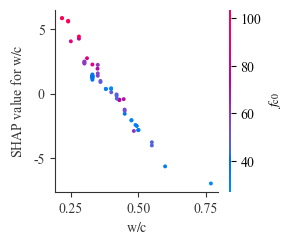

In [19]:
import shap
import matplotlib.pyplot as plt

# 设置全局字体为 Times New Roman，小字号适合小图
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

# 单位换算：厘米转英寸
cm = 1 / 2.54
fig_width, fig_height = 8 * cm, 6 * cm

# 转换 SHAP 值为 numpy 数组
shap_values_array = shap_values.values

# 绘制依赖图（主特征为 w/c，交互特征为 f_c0）
shap.dependence_plot(
    "w/c",
    shap_values_array,
    X_test,
    interaction_index="fc0/MPa",
    show=False,
    dot_size=8  # 适合小图
)

# 设置图像尺寸
fig = plt.gcf()
fig.set_size_inches(fig_width, fig_height)

# 设置坐标轴标签
plt.xlabel(FEATURE_LABELS['w/c'], fontsize=10)
plt.ylabel("")
plt.gca().set_ylabel(r'SHAP value for $\mathrm{w}/\mathrm{c}$', fontsize=10, rotation=90, labelpad=6)

# 坐标轴刻度字体大小
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 设置 colorbar 标签与刻度
ax = plt.gca()
cbar = ax.collections[0].colorbar
cbar.set_label(FEATURE_LABELS['fc0/MPa'], fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=10)

# 手动调整图像边距，避免文字被裁剪
fig.subplots_adjust(left=0.20, right=0.85, top=0.95, bottom=0.18)

# 保存图像为高分辨率 PNG
display_and_save(plt.gcf(), "images/4_dependence_plot.png", dpi=600, bbox_inches="tight")


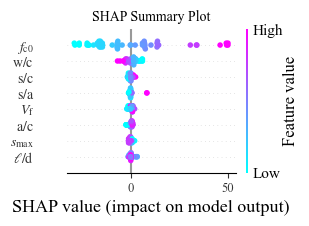

In [22]:
# 蜂群图3
shap.plots.beeswarm(shap_values,max_display=15,
                    color=plt.get_cmap("cool"), show=False)
cm = 1 / 2.54
fig = plt.gcf()
fig.set_size_inches(8 * cm, 6 * cm)  # 设置图形大小为 8cm x 8cm

# 设置标题和字体
plt.title("SHAP Summary Plot", fontsize=10, fontfamily='Times New Roman')
plt.xticks(fontsize=9, fontfamily='Times New Roman')
plt.yticks(fontsize=10, fontfamily='Times New Roman')

# 调整布局并保存图片
plt.tight_layout()
display_and_save(plt.gcf(), "images/5_beeswarm_plot4.png", dpi=600, bbox_inches="tight")


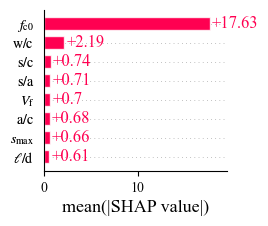

图像已保存到：D:/de/ml/images/6_shap_summary_plot2.png


In [24]:
import matplotlib.pyplot as plt
import shap

# 绘制 SHAP 摘要图（条形图）
shap.plots.bar(shap_values, show=False)

# 单位换算：厘米转英寸
cm = 1 / 2.54

# 获取当前图形并设置大小为 8cm × 8cm
fig = plt.gcf()
fig.set_size_inches(7 * cm, 6 * cm)

# 设置字体为 Times New Roman
plt.xticks(fontsize=10, fontfamily='Times New Roman')
plt.yticks(fontsize=10, fontfamily='Times New Roman')

# 自动调整布局，避免裁剪问题
plt.tight_layout()

# 保存图片
save_path = "images/6_shap_summary_plot2.png"
display_and_save(plt.gcf(), save_path, dpi=600, bbox_inches="tight")

print(f"图像已保存到：{save_path}")


ExactExplainer explainer: 217it [06:00,  1.71s/it]                                                                     


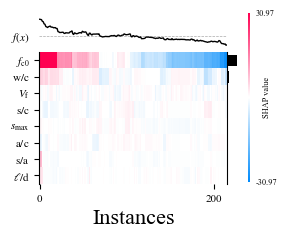

图像已保存到：images/6_shap_train.png


In [17]:
import shap
import matplotlib.pyplot as plt

# 计算 SHAP 值
X_train = train_data.drop(columns=["fc/MPa"])
shap_values = explainer(X_train)
shap_values = apply_shap_feature_labels(shap_values, X_train.columns)


# 单位换算：厘米转英寸
cm = 1 / 2.54

# 显式使用 matplotlib 绘图，并设置图形大小为 8cm × 8cm
fig = plt.figure(figsize=(8 * cm, 8 * cm))

# 绘制热力图
shap.plots.heatmap(shap_values, show=False)

# 强制设置图形大小
fig.set_size_inches(8 * cm, 8 * cm)

# 设置全局字体
plt.xticks(fontsize=8, fontfamily='Times New Roman')
plt.yticks(fontsize=8, fontfamily='Times New Roman')

# 修改颜色条右侧的字体大小
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=6)  # 设置刻度字体
cbar.set_ylabel('SHAP value', fontsize=6, fontfamily='Times New Roman')

# 自动调整布局，避免裁剪
plt.tight_layout()

# 保存图片
save_path = "images/6_shap_train.png"
display_and_save(plt.gcf(), save_path, dpi=600, bbox_inches="tight")

print(f"图像已保存到：{save_path}")


ExactExplainer explainer: 55it [01:27,  1.82s/it]                                                                      


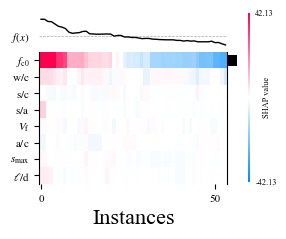

图像已保存到：images/6_shap_test_smaller_label.png


In [18]:
import shap
import matplotlib.pyplot as plt

# 计算 SHAP 值
X_train = train_data.drop(columns=["fc/MPa"])
shap_values = explainer(X_test)
shap_values = apply_shap_feature_labels(shap_values, X_test.columns)

# 单位换算：厘米转英寸
cm = 1 / 2.54

# 显式使用 matplotlib 绘图，并设置图形大小为 8cm × 8cm
fig = plt.figure(figsize=(8 * cm, 8 * cm))

# 绘制热力图
shap.plots.heatmap(shap_values, show=False)

# 强制设置图形大小
fig.set_size_inches(8 * cm, 8 * cm)

# 设置全局字体
plt.xticks(fontsize=8, fontfamily='Times New Roman')
plt.yticks(fontsize=8, fontfamily='Times New Roman')

# 修改颜色条右侧的字体大小
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=6)  # 设置刻度字体
cbar.set_ylabel('SHAP value', fontsize=6, fontfamily='Times New Roman')

# 自动调整布局，避免裁剪
plt.tight_layout()

# 保存图片
save_path = "images/6_shap_test_smaller_label.png"
display_and_save(plt.gcf(), save_path, dpi=600, bbox_inches="tight")

print(f"图像已保存到：{save_path}")
